# Stat Arb in Crypto


In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from data_loader import load_universe, get_returns, UNIVERSE
from signals import tsmom, xsmom, mean_reversion, normalize_signal, combine_signals, smooth_signal
from optimization import compute_optimal_weights
from backtest import Backtester, get_stats, print_stats, calc_drawdown_series

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)


In [2]:
%load_ext autoreload
%autoreload 2

## Data Loading


In [41]:
# load hourly prices (will cache after first fetch)
px = load_universe(UNIVERSE, start='2022-01-01', refresh=False)
ret = get_returns(px)

print(f"Data shape: {px.shape}")
print(f"Date range: {px.index[0]} to {px.index[-1]}")
px.tail()


loading cached data from /Users/euler/Desktop/GT/Quant/Projects/StatArbParentDir/stat-arb-research/data/universe_BTCUSDT_ETHUSDT_SOLUSDT_etc.parquet
Data shape: (35142, 16)
Date range: 2022-01-01 00:00:00 to 2026-01-04 05:00:00


,BTCUSDT,ETHUSDT,SOLUSDT,BNBUSDT,XRPUSDT,ADAUSDT,DOGEUSDT,AVAXUSDT,TRXUSDT,DOTUSDT,LINKUSDT,MATICUSDT,LTCUSDT,BCHUSDT,ATOMUSDT,UNIUSDT
2026-01-04 01:00:00,91235.37,3150.17,133.96,882.54,2.0353,0.3942,0.14653,13.96,0.2954,2.128,13.36,0.3794,82.28,644.8,2.253,5.969
2026-01-04 02:00:00,91124.00,3141.12,133.73,880.69,2.0311,0.3938,0.14716,13.92,0.2953,2.126,13.32,0.3794,82.19,644.1,2.244,5.936
2026-01-04 03:00:00,91236.78,3147.36,134.62,883.14,2.0581,0.3995,0.15102,14.01,0.2949,2.130,13.36,0.3794,82.54,646.3,2.255,5.942
2026-01-04 04:00:00,91408.00,3148.39,134.31,888.81,2.0610,0.3978,0.15207,14.00,0.2944,2.135,13.37,0.3794,82.44,648.9,2.250,5.919
2026-01-04 05:00:00,91408.00,3148.39,134.31,888.80,2.0618,0.3978,0.15182,14.01,0.2945,2.137,13.36,0.3794,82.41,649.9,2.252,5.916


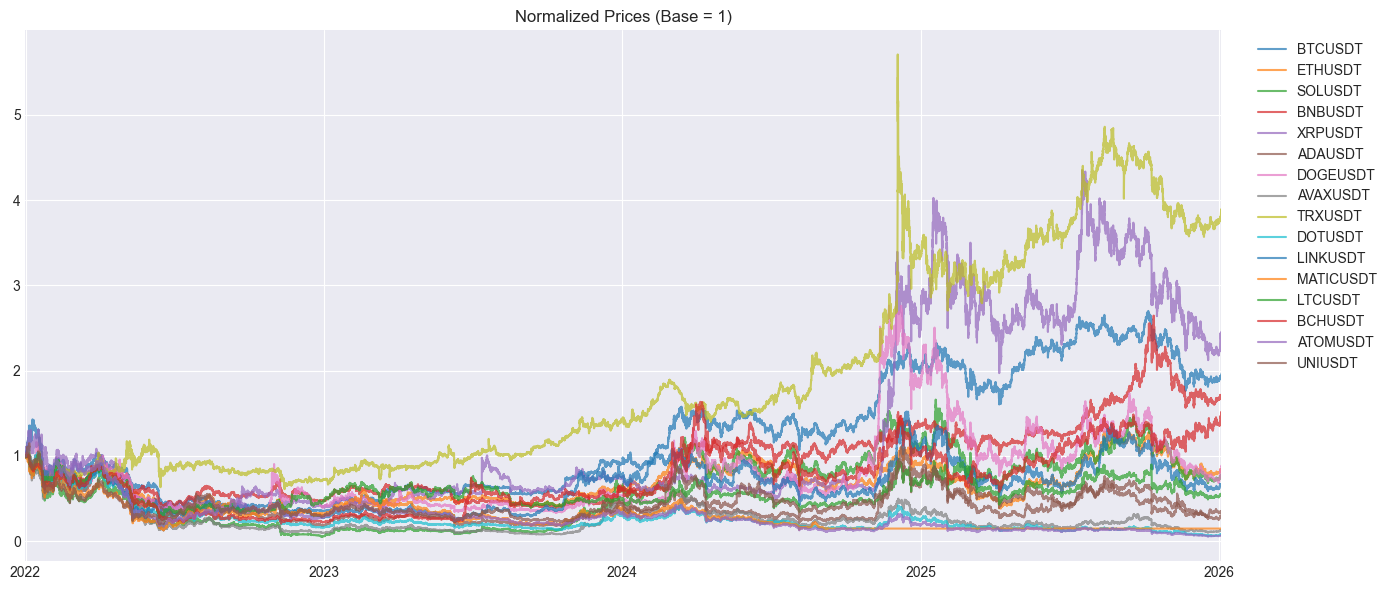

In [42]:
# quick look at cumulative returns
fig, ax = plt.subplots(figsize=(14, 6))
(px / px.iloc[0]).plot(ax=ax, alpha=0.7) #! alpha is transparency lol; for overlay
ax.set_title('Normalized Prices (Base = 1)')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()


## Signal Generation


In [43]:
# params for signals - INCREASED lookbacks to reduce turnover
TSMOM_LOOKBACK = 336   # 14 days (was 7 days)
XSMOM_LOOKBACK = 168   # 7 days (was 3 days)
MEANREV_LOOKBACK = 72  # 3 days (was 1 day)
SIGNAL_SMOOTH_HALFLIFE = 48  # 2-day EMA halflife for smoothing

# compute raw signals
sig_tsmom = tsmom(px, TSMOM_LOOKBACK)
sig_xsmom = xsmom(ret, XSMOM_LOOKBACK)
sig_meanrev = mean_reversion(px, MEANREV_LOOKBACK)

# normalize each signal (dollar neutral, fully invested)
sig_tsmom_norm = normalize_signal(sig_tsmom)
sig_xsmom_norm = normalize_signal(sig_xsmom)
sig_meanrev_norm = normalize_signal(sig_meanrev)

# apply EMA smoothing to reduce signal noise and turnover
sig_tsmom_norm = normalize_signal(smooth_signal(sig_tsmom_norm, SIGNAL_SMOOTH_HALFLIFE))
sig_xsmom_norm = normalize_signal(smooth_signal(sig_xsmom_norm, SIGNAL_SMOOTH_HALFLIFE))
sig_meanrev_norm = normalize_signal(smooth_signal(sig_meanrev_norm, SIGNAL_SMOOTH_HALFLIFE))

In [44]:
print("Signal shapes:")
print(f"\tTSMOM: {sig_tsmom_norm.shape}")
print(f"\tXSMOM: {sig_xsmom_norm.shape}")
print(f"\tMeanRev: {sig_meanrev_norm.shape}")

Signal shapes:
	TSMOM: (35142, 16)
	XSMOM: (35142, 16)
	MeanRev: (35142, 16)


In [45]:
# combine signals with equal weight
combined_signal = combine_signals(
    [sig_tsmom_norm, sig_xsmom_norm, sig_meanrev_norm],
    weights=[0.33, 0.33, 0.34]  # roughly equal
)

# re-normalize combined signal
combined_signal = normalize_signal(combined_signal)


In [46]:
print("Combined signal check:")
print(f"\tSum of abs weights: {combined_signal.abs().sum(axis=1).mean():.4f} (should be ~1)")
print(f"\tSum of weights: {combined_signal.sum(axis=1).mean():.6f} (should be ~0)")

Combined signal check:
	Sum of abs weights: 1.0000 (should be ~1)
	Sum of weights: 0.000000 (should be ~0)


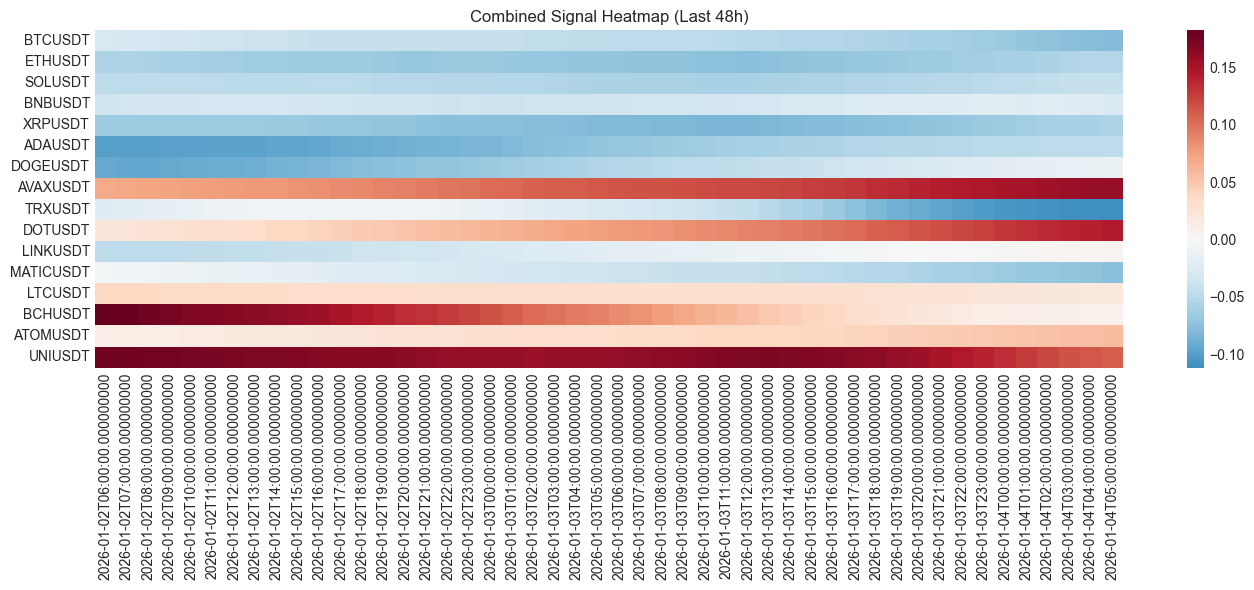

In [47]:
# viz: signal heatmap for last 48 hours
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(combined_signal.tail(48).T, cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Combined Signal Heatmap (Last 48h)')
plt.tight_layout()


## Portfolio Optimization


In [48]:
# compute optimal weights using general weighting scheme
# sigma^-1 * mu with vol targeting + weight smoothing

COV_WINDOW = 720    # 30 days in hours
SHRINKAGE = 0.15
TARGET_VOL = 0.20   # 20% annualized
MAX_LEVERAGE = 3.0
WEIGHT_SMOOTH = 0.05  # EMA smoothing: only 5% new weight per period (reduces turnover)

# this takes a minute...
print("Computing optimal weights (this may take a bit)...")
opt_weights = compute_optimal_weights(
    ret, 
    combined_signal,
    cov_window=COV_WINDOW,
    shrinkage=SHRINKAGE,
    target_vol=TARGET_VOL,
    max_leverage=MAX_LEVERAGE,
    weight_smooth=WEIGHT_SMOOTH
)


Computing optimal weights (this may take a bit)...


In [49]:
print(f"Weights shape: {opt_weights.shape}")
opt_weights.tail()

Weights shape: (34422, 16)


,BTCUSDT,ETHUSDT,SOLUSDT,BNBUSDT,XRPUSDT,ADAUSDT,DOGEUSDT,AVAXUSDT,TRXUSDT,DOTUSDT,LINKUSDT,MATICUSDT,LTCUSDT,BCHUSDT,ATOMUSDT,UNIUSDT
2026-01-04 01:00:00,-0.047797,-0.058733,-0.009039,-0.050920,-0.085084,-0.055814,-0.043758,0.155895,-0.249751,0.082681,0.007093,0.019096,0.091589,0.091948,0.039665,0.112930
2026-01-04 02:00:00,-0.048993,-0.056245,-0.008220,-0.047530,-0.081645,-0.053622,-0.040528,0.153523,-0.254139,0.082633,0.008124,0.019331,0.089358,0.089166,0.039041,0.109745
2026-01-04 03:00:00,-0.050293,-0.053768,-0.007396,-0.044348,-0.078261,-0.051526,-0.037432,0.151243,-0.258271,0.082622,0.009100,0.019555,0.087176,0.086513,0.038456,0.106629
2026-01-04 04:00:00,-0.051690,-0.051308,-0.006545,-0.041512,-0.074934,-0.049526,-0.034467,0.149059,-0.262083,0.082646,0.010034,0.019769,0.085056,0.083978,0.037924,0.103598
2026-01-04 05:00:00,-0.053157,-0.048859,-0.005670,-0.039029,-0.071681,-0.047603,-0.031632,0.146970,-0.265590,0.082686,0.010934,0.019974,0.083006,0.081556,0.037437,0.100658


In [50]:
opt_weights.abs().sum(axis=1).max()

np.float64(2.9874719978374027)

In [51]:
opt_weights.sum(axis=1).max() #! fixed

np.float64(6.661338147750939e-16)

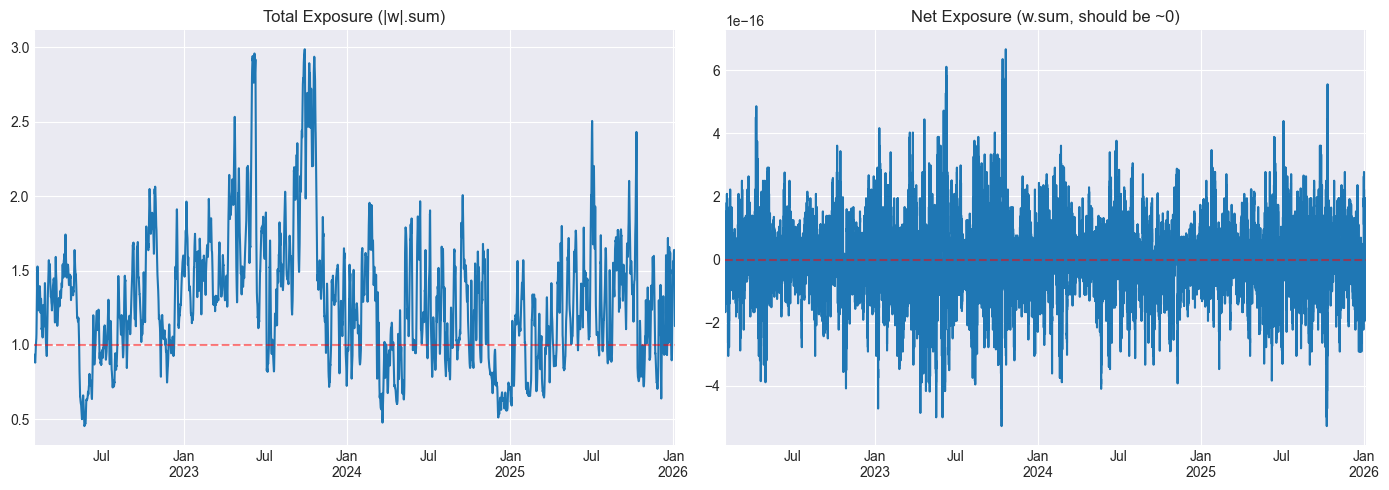

In [52]:
# check weight distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# abs sum of weights over time
opt_weights.abs().sum(axis=1).plot(ax=axes[0])
axes[0].set_title('Total Exposure (|w|.sum)')
axes[0].axhline(1.0, color='red', linestyle='--', alpha=0.5)

# sum of weights (should be ~0 for dollar neutral)
opt_weights.sum(axis=1).plot(ax=axes[1])
axes[1].set_title('Net Exposure (w.sum, should be ~0)')
axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()


## Backtest


In [53]:
# run backtest
TCOST_BPS = 5  # 5 bps per trade

bt = Backtester(ret, opt_weights, tcost_bps=TCOST_BPS)
results = bt.run()

# print performance
print_stats(results['net_ret'], 'Stat Arb Strategy (Net)')
print_stats(results['gross_ret'], 'Stat Arb Strategy (Gross)')

print(f"\nAvg Daily Turnover: {results['turnover'].mean():.2%}")
print(f"Avg Hourly Tcost: {results['tcost'].mean()*1e4:.2f} bps")



Stat Arb Strategy (Net) Performance:
  Sharpe:     0.25
  Sortino:    0.36
  Ann Return: 5.7%
  Ann Vol:    22.4%
  Max DD:     -40.5%
  Total Ret:  13.3%

Stat Arb Strategy (Gross) Performance:
  Sharpe:     0.64
  Sortino:    0.89
  Ann Return: 14.3%
  Ann Vol:    22.4%
  Max DD:     -36.5%
  Total Ret:  58.8%

Avg Daily Turnover: 1.96%
Avg Hourly Tcost: 0.10 bps


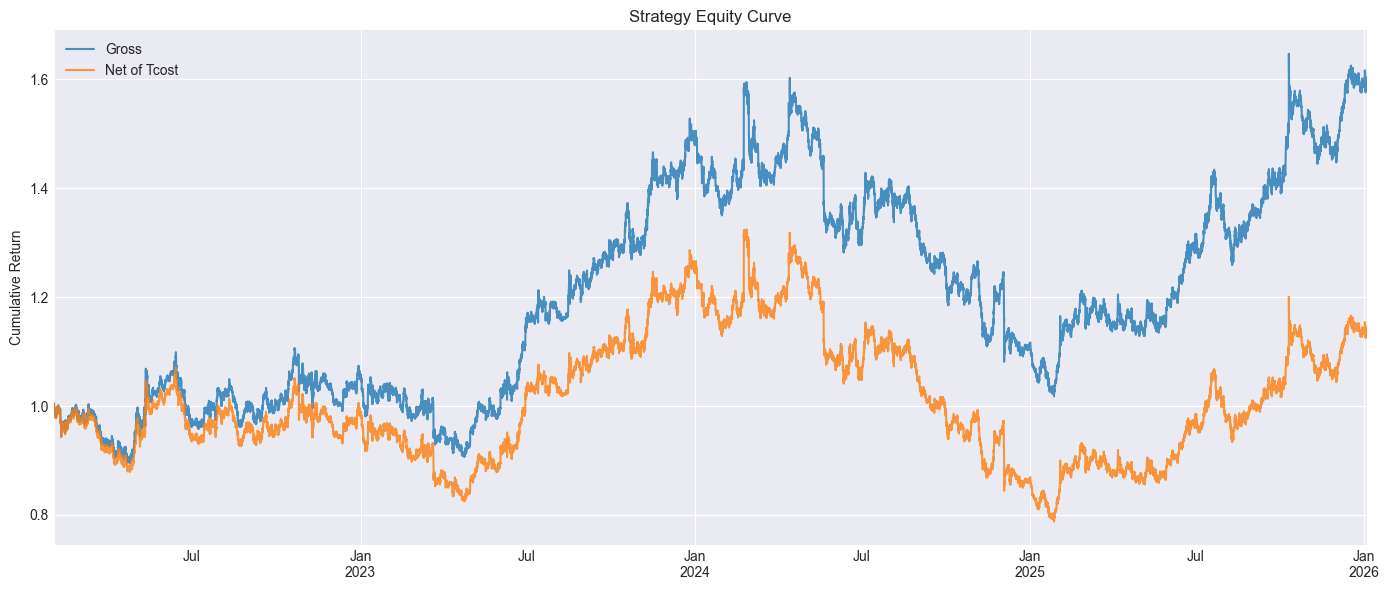

In [54]:
# equity curve
equity_net = bt.get_equity_curve(use_net=True)
equity_gross = bt.get_equity_curve(use_net=False)

fig, ax = plt.subplots(figsize=(14, 6))
equity_gross.plot(ax=ax, label='Gross', alpha=0.8)
equity_net.plot(ax=ax, label='Net of Tcost', alpha=0.8)
ax.set_title('Strategy Equity Curve')
ax.set_ylabel('Cumulative Return')
ax.legend()
plt.tight_layout()


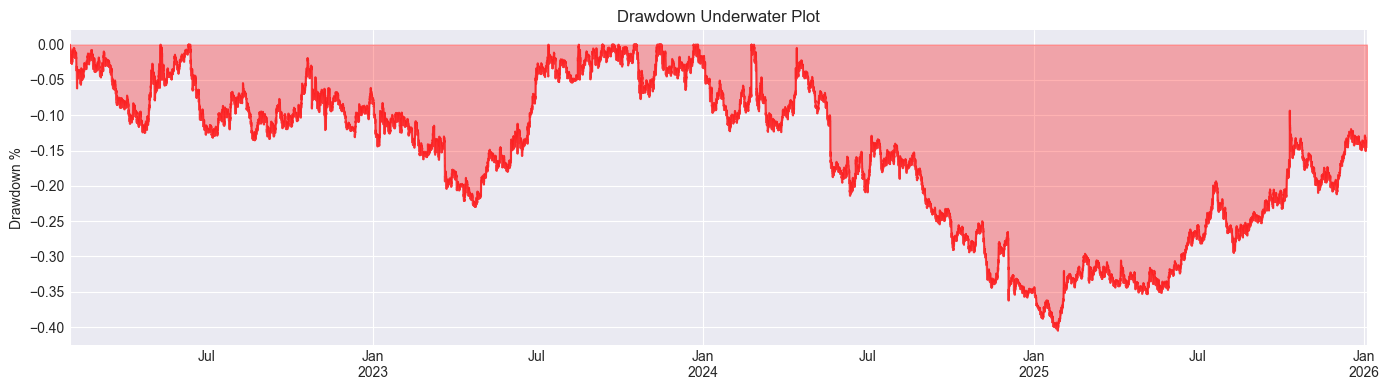

In [55]:
# drawdown underwater plot
dd = calc_drawdown_series(equity_net)

fig, ax = plt.subplots(figsize=(14, 4))
dd.plot(ax=ax, color='red', alpha=0.7)
ax.fill_between(dd.index, dd.values, 0, color='red', alpha=0.3)
ax.set_title('Drawdown Underwater Plot')
ax.set_ylabel('Drawdown %')
plt.tight_layout()


## Benchmark Comparison


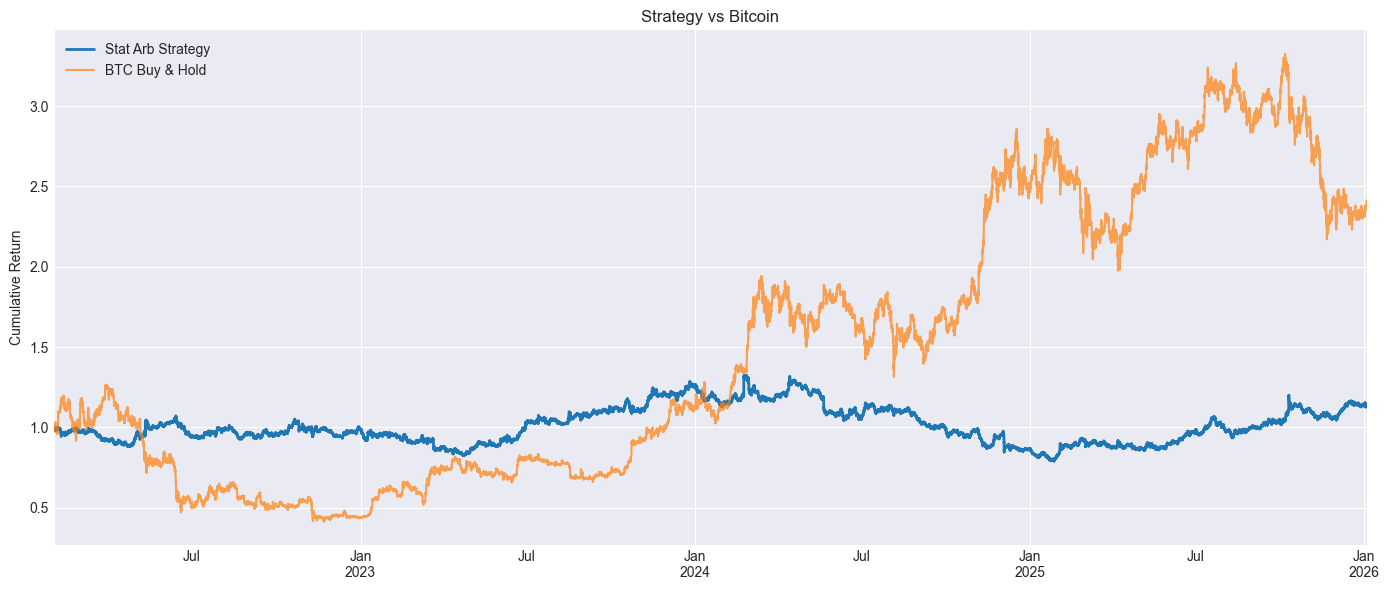

In [56]:
# compare to BTC buy-and-hold
btc_ret = ret['BTCUSDT'].loc[results['net_ret'].index]
btc_equity = (1 + btc_ret).cumprod()

fig, ax = plt.subplots(figsize=(14, 6))
equity_net.plot(ax=ax, label='Stat Arb Strategy', linewidth=2)
btc_equity.plot(ax=ax, label='BTC Buy & Hold', alpha=0.7)
ax.set_title('Strategy vs Bitcoin')
ax.set_ylabel('Cumulative Return')
ax.legend()
plt.tight_layout()


In [57]:
# BTC stats for comparison
print_stats(btc_ret, 'BTC Buy & Hold')



BTC Buy & Hold Performance:
  Sharpe:     0.69
  Sortino:    0.88
  Ann Return: 35.4%
  Ann Vol:    51.0%
  Max DD:     -67.4%
  Total Ret:  141.3%


## Alpha/Beta Purification Regression


In [58]:
# regress strategy returns on BTC to separate alpha from beta
#! strat_ret = alpha + beta * btc_ret + epsilon; alpha contribution --> alpha + residual; beta contribution --> beta * btc_ret
#! mean of alpha contribution --> alpha; mean of beta contribution --> beta * mean(btc_ret)

strat_ret = results['net_ret'].dropna()
btc_ret_aligned = btc_ret.loc[strat_ret.index].dropna()

# align
common = strat_ret.index.intersection(btc_ret_aligned.index)
Y = strat_ret.loc[common]
X = btc_ret_aligned.loc[common]

# add constant for alpha (intercept, 1s)
X_const = sm.add_constant(X)

# fit OLS
model = sm.OLS(Y, X_const).fit()


In [59]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     184.5
Date:                Thu, 08 Jan 2026   Prob (F-statistic):           6.49e-42
Time:                        17:48:04   Log-Likelihood:             1.5903e+05
No. Observations:               34422   AIC:                        -3.181e+05
Df Residuals:                   34420   BIC:                        -3.180e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7.763e-06   1.28e-05      0.604      0.546   -1.74e-05    3.29e-05
BTCUSDT       -0.0320      0.002    -13.583      0.000      -0.037      -0.027
==============================================================================
Omnibus:                    29839.083   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):         29040182.530
Skew:                           2.998   Prob(JB):                         0.00
Kurtosis:                     145.168   Cond. No.                         183.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [60]:
# extract alpha and beta
alpha = model.params['const']
beta = model.params['BTCUSDT']

print(f"\nAlpha (hourly): {alpha:.6f}")
print(f"Alpha (annualized): {alpha * 24 * 365 * 100:.2f}%")
print(f"Alpha t-stat: {model.tvalues['const']:.2f}")
print(f"\nBeta: {beta:.4f}")
print(f"Beta t-stat: {model.tvalues['BTCUSDT']:.2f}")



Alpha (hourly): 0.000008
Alpha (annualized): 6.80%
Alpha t-stat: 0.60

Beta: -0.0320
Beta t-stat: -13.58


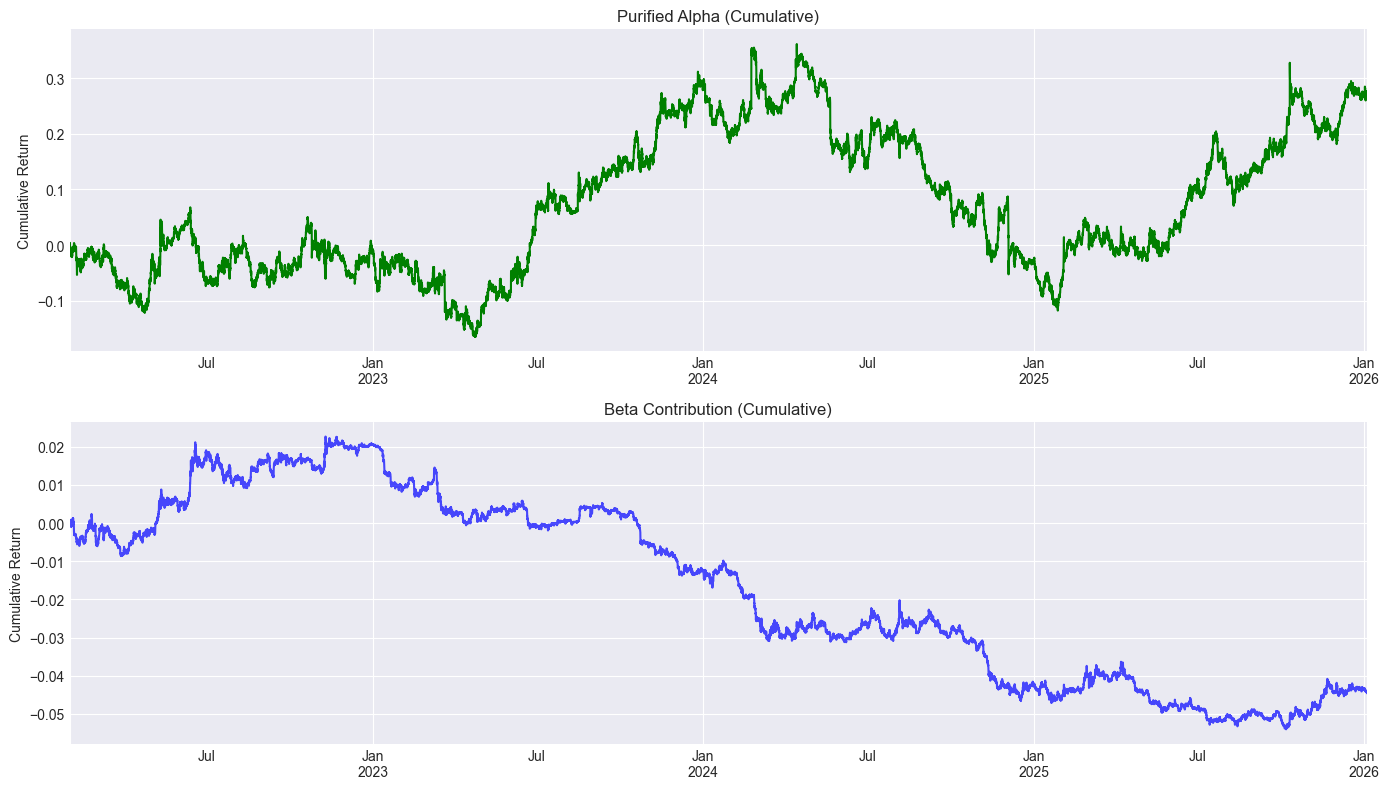

In [61]:
# compute purified alpha (residual from regression)
alpha_contribution = model.params['const'] + model.resid
beta_contribution = model.params['BTCUSDT'] * X

# plot purified alpha
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

alpha_contribution.cumsum().plot(ax=axes[0], color='green')
axes[0].set_title('Purified Alpha (Cumulative)')
axes[0].set_ylabel('Cumulative Return')

beta_contribution.cumsum().plot(ax=axes[1], color='blue', alpha=0.7)
axes[1].set_title('Beta Contribution (Cumulative)')
axes[1].set_ylabel('Cumulative Return')

plt.tight_layout()


In [62]:
# information ratio of purified alpha
ir = alpha_contribution.mean() / alpha_contribution.std() * np.sqrt(24*365)
print(f"Information Ratio (Purified Alpha): {ir:.2f}")

Information Ratio (Purified Alpha): 0.30


In [63]:
# verify alpha is uncorrelated to market
corr = alpha_contribution.corr(X)
print(f"Correlation of Alpha to BTC: {corr:.4f} (should be ~0)")

Correlation of Alpha to BTC: -0.0000 (should be ~0)


## 7. Individual Signal Analysis


In [64]:
#! backtesting each signal individually to see contribution

def quick_backtest(signal, ret, name):
    """run a quick backtest on a normalized signal"""
    bt = Backtester(ret, signal, tcost_bps=5)
    res = bt.run()
    stats = get_stats(res['net_ret'])
    return stats

# individual signal backtests
stats_tsmom = quick_backtest(sig_tsmom_norm, ret, 'TSMOM')
stats_xsmom = quick_backtest(sig_xsmom_norm, ret, 'XSMOM')
stats_meanrev = quick_backtest(sig_meanrev_norm, ret, 'MeanRev')

# compare
comparison = pd.DataFrame({
    'TSMOM': stats_tsmom,
    'XSMOM': stats_xsmom,
    'MeanRev': stats_meanrev,
})
comparison


,TSMOM,XSMOM,MeanRev
sharpe,0.866281,0.615901,-1.693811
sortino,1.223942,0.838635,-2.010167
ann_ret,0.231741,0.133949,-0.379027
ann_vol,0.267513,0.217484,0.223772
max_dd,-0.244765,-0.297160,-0.819563
total_ret,1.196301,0.556696,-0.802383


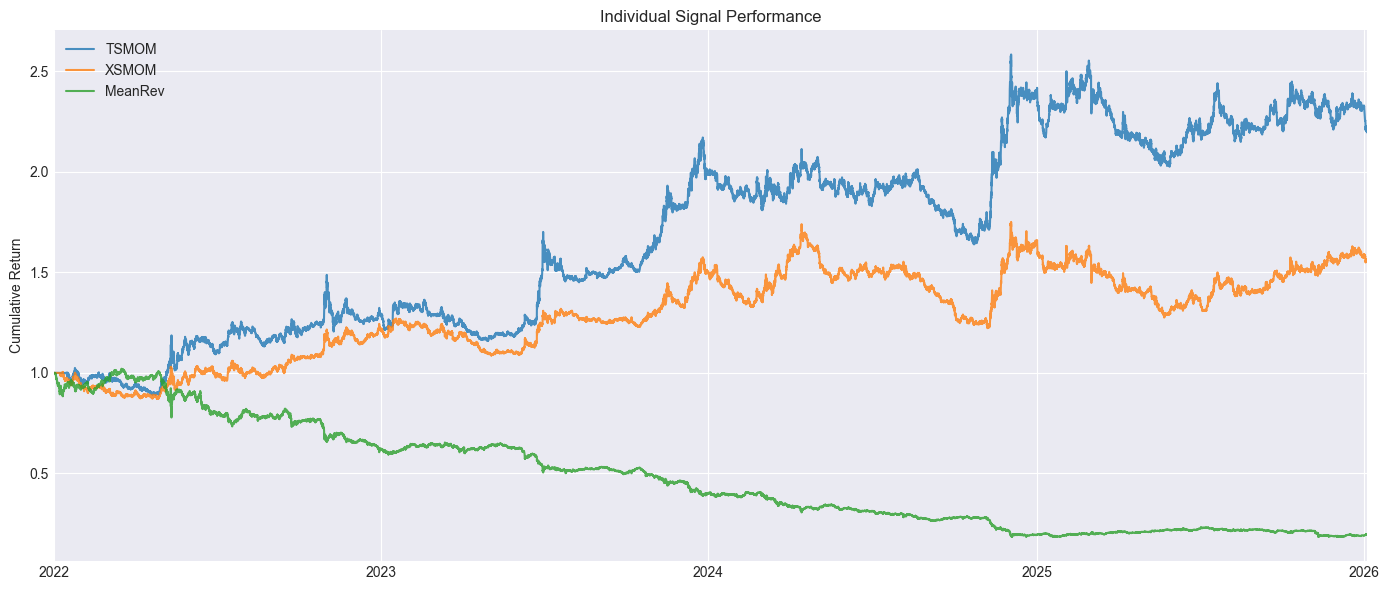

In [65]:
# equity curves for each signal
fig, ax = plt.subplots(figsize=(14, 6))

for sig, name in [(sig_tsmom_norm, 'TSMOM'), 
                   (sig_xsmom_norm, 'XSMOM'), 
                   (sig_meanrev_norm, 'MeanRev')]:
    bt = Backtester(ret, sig, tcost_bps=5)
    bt.run()
    eq = bt.get_equity_curve()
    eq.plot(ax=ax, label=name, alpha=0.8)

ax.set_title('Individual Signal Performance')
ax.set_ylabel('Cumulative Return')
ax.legend()
plt.tight_layout()


## Summary Stats Table


In [66]:
# final summary
strat_stats = get_stats(results['net_ret'])
btc_stats = get_stats(btc_ret.loc[results['net_ret'].index])

summary_raw = pd.DataFrame({
    'Stat Arb (Net)': strat_stats,
    'BTC Buy&Hold': btc_stats
})

# formatting nicely
summary = pd.DataFrame(index=summary_raw.index, columns=summary_raw.columns, dtype=object)
summary.loc['sharpe'] = summary_raw.loc['sharpe'].round(2)
summary.loc['sortino'] = summary_raw.loc['sortino'].round(2)
summary.loc['ann_ret'] = (summary_raw.loc['ann_ret'] * 100).round(1).astype(str) + '%'
summary.loc['ann_vol'] = (summary_raw.loc['ann_vol'] * 100).round(1).astype(str) + '%'
summary.loc['max_dd'] = (summary_raw.loc['max_dd'] * 100).round(1).astype(str) + '%'
summary.loc['total_ret'] = (summary_raw.loc['total_ret'] * 100).round(1).astype(str) + '%'


In [67]:
summary

,Stat Arb (Net),BTC Buy&Hold
sharpe,0.25,0.69
sortino,0.36,0.88
ann_ret,5.7%,35.4%
ann_vol,22.4%,51.0%
max_dd,-40.5%,-67.4%
total_ret,13.3%,141.3%


In [68]:
# additional metrics
print("Additional Metrics:")
print(f"\tAverage Turnover: {results['turnover'].mean():.2%}")
print(f"\tAnnualized Alpha: {alpha * 24 * 365 * 100:.2f}%")
print(f"\tMarket Beta: {beta:.3f}")
print(f"\tInformation Ratio: {ir:.2f}")


Additional Metrics:
	Average Turnover: 1.96%
	Annualized Alpha: 6.80%
	Market Beta: -0.032
	Information Ratio: 0.30
